In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("data/05_flats_FeatureEngineered.csv")

In [3]:
df.shape

(2904, 50)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2904 entries, 0 to 2903
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area_sqm                2904 non-null   float64
 1   bedroom                 2904 non-null   float64
 2   bathroom                2904 non-null   float64
 3   balcony                 2904 non-null   float64
 4   addl_room               2904 non-null   float64
 5   sector                  2904 non-null   object 
 6   landmark_count          2904 non-null   float64
 7   has_hospital_or_clinic  2904 non-null   float64
 8   has_police_stn          2904 non-null   float64
 9   has_fire_stn            2904 non-null   float64
 10  has_mall                2904 non-null   float64
 11  has_market              2904 non-null   float64
 12  has_park                2904 non-null   float64
 13  has_bank_or_atm         2904 non-null   float64
 14  has_institute           2904 non-null   

In [5]:
df.head(2)

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,stove,tv,washing machine,water purifier,area_type,floor_rise,age,society,city,price_cr
0,83.61,2.0,2.0,1.0,0.0,sector 7,50.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,carpet,mid,new,maa bhagwati residency,gurgaon,0.45
1,60.39,2.0,2.0,1.0,0.0,sector 3,48.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,carpet,low,old,apna enclave,gurgaon,0.50


In [6]:
df.columns

Index(['area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe', 'fan',
       'light', 'wardrobe', 'ac', 'bed', 'chimney', 'curtains', 'dining table',
       'exhaust fan', 'geyser', 'modular kitchen', 'microwave', 'fridge',
       'sofa', 'stove', 'tv', 'washing machine', 'water purifier', 'area_type',
       'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='object')

In [7]:
df.isnull().sum()

area_sqm                  0
bedroom                   0
bathroom                  0
balcony                   0
addl_room                 0
sector                    0
landmark_count            0
has_hospital_or_clinic    0
has_police_stn            0
has_fire_stn              0
has_mall                  0
has_market                0
has_park                  0
has_bank_or_atm           0
has_institute             0
has_airport               0
has_rly_stn               0
has_metro_stn             0
has_expy                  0
has_petrol_pump           0
has_hotel                 0
has_temple_or_church      0
has_famous_chowk          0
has_club                  0
has_stadium               0
has_restro_cafe           0
fan                       0
light                     0
wardrobe                  0
ac                        0
bed                       0
chimney                   0
curtains                  0
dining table              0
exhaust fan               0
geyser              

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_sqm,2904.0,NaN,NaN,NaN,255.452754,2120.105484,6.69,120.77,161.19,199.74,68483.2
bedroom,2904.0,NaN,NaN,NaN,2.809229,0.789248,1.0,2.0,3.0,3.0,6.0
bathroom,2904.0,NaN,NaN,NaN,2.967975,1.04333,1.0,2.0,3.0,4.0,7.0
balcony,2904.0,NaN,NaN,NaN,2.462466,0.787411,0.0,2.0,3.0,3.0,3.0
addl_room,2904.0,NaN,NaN,NaN,0.577135,0.494099,0.0,0.0,1.0,1.0,1.0
sector,2904,91,sector 33,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landmark_count,2904.0,NaN,NaN,NaN,14.306818,11.395584,3.0,9.0,10.0,14.0,50.0
has_hospital_or_clinic,2904.0,NaN,NaN,NaN,0.801653,0.398824,0.0,1.0,1.0,1.0,1.0
has_police_stn,2904.0,NaN,NaN,NaN,0.014807,0.120801,0.0,0.0,0.0,0.0,1.0
has_fire_stn,2904.0,NaN,NaN,NaN,0.000689,0.026239,0.0,0.0,0.0,0.0,1.0


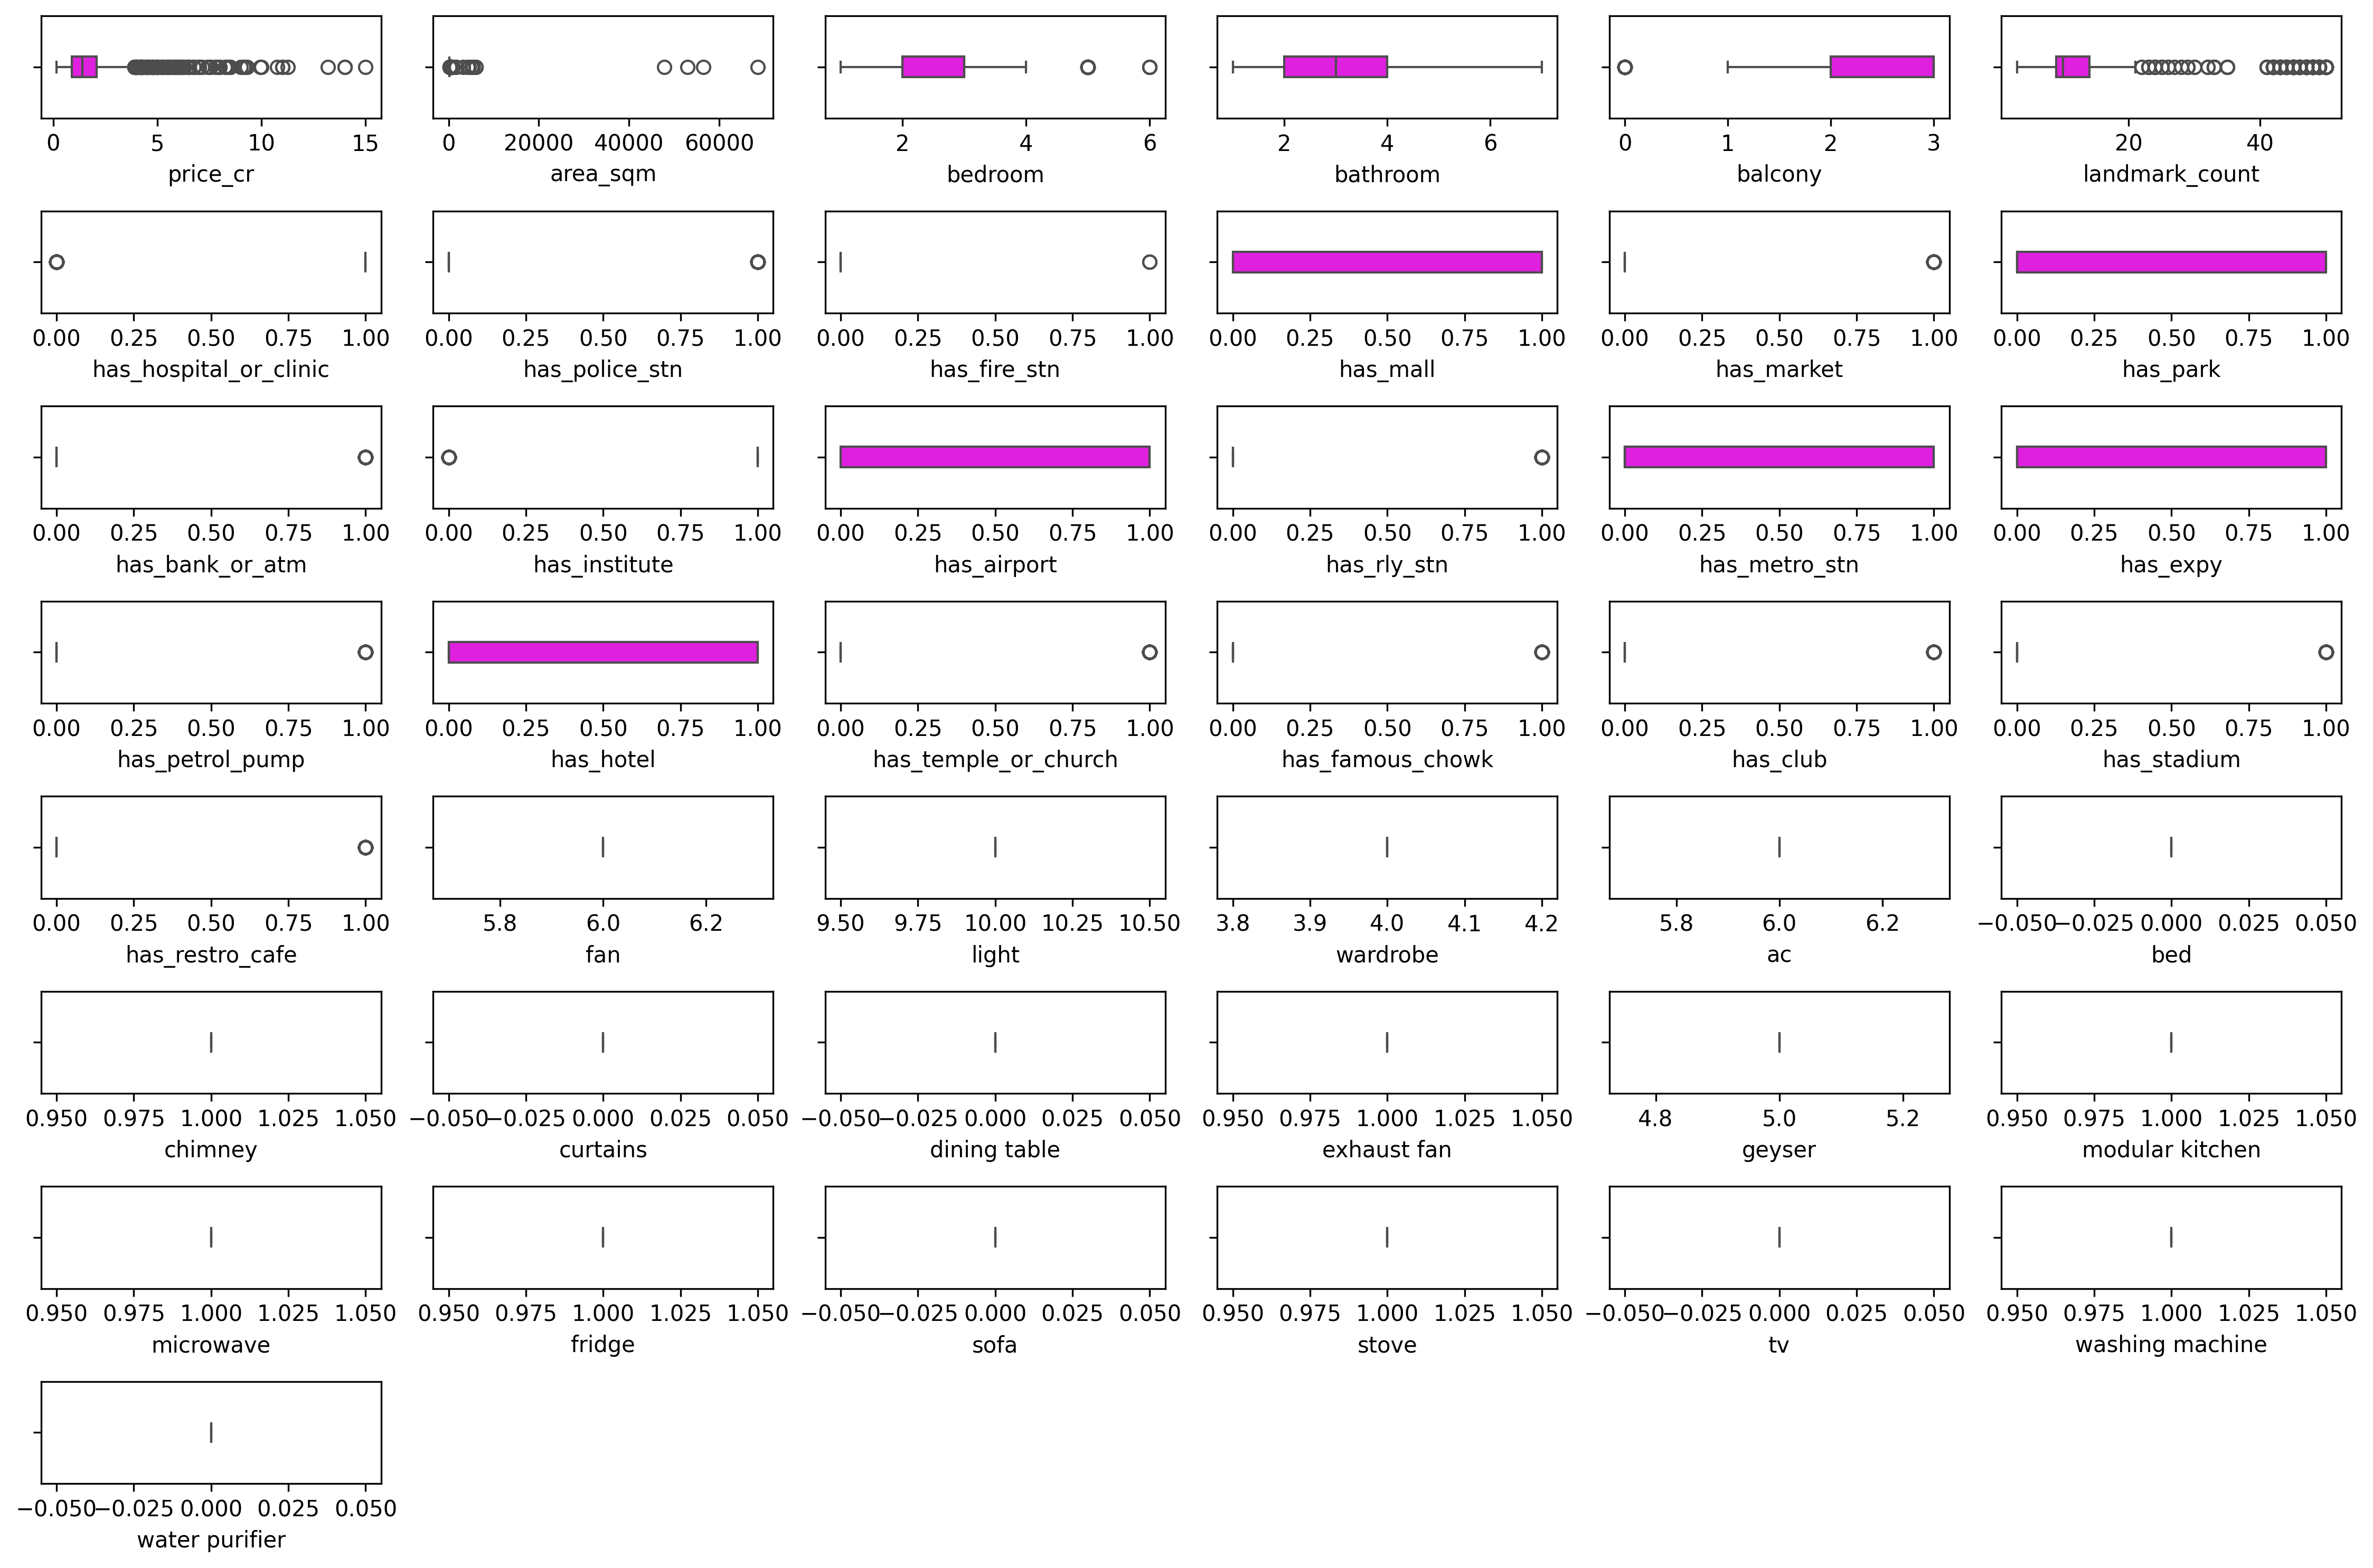

In [9]:
fig = plt.figure(figsize=(15,10),dpi=300)
i = 0
for col in ['price_cr', 'area_sqm', 'bedroom', 'bathroom', 'balcony','landmark_count', 
            'has_hospital_or_clinic', 'has_police_stn','has_fire_stn', 'has_mall', 'has_market', 
            'has_park', 'has_bank_or_atm','has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
            'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church','has_famous_chowk', 
            'has_club', 'has_stadium', 'has_restro_cafe', 'fan','light', 'wardrobe', 'ac', 'bed', 
            'chimney', 'curtains', 'dining table','exhaust fan', 'geyser', 'modular kitchen',
            'microwave', 'fridge','sofa', 'stove', 'tv', 'washing machine', 'water purifier']:
    if df[col].dtype in ('int64', 'float64'):
        i += 1
        plt.subplot(df.shape[1]//6, 6, i)
        sns.boxplot(data=df, x=col, width=0.2, color='magenta')
        plt.tight_layout()
plt.show()

In [10]:
df.shape

(2904, 50)

In [11]:
print(df['fan'].value_counts())
print(df['light'].value_counts())
print(df['wardrobe'].value_counts())
print(df['ac'].value_counts())
print(df['bed'].value_counts())
print(df['chimney'].value_counts())
print(df['curtains'].value_counts())
print(df['dining table'].value_counts())
print(df['exhaust fan'].value_counts())
print(df['geyser'].value_counts())
print(df['modular kitchen'].value_counts())
print(df['microwave'].value_counts())
print(df['fridge'].value_counts())
print(df['sofa'].value_counts())
print(df['stove'].value_counts())
print(df['tv'].value_counts())
print(df['washing machine'].value_counts())
print(df['water purifier'].value_counts())

fan
6.0    2904
Name: count, dtype: int64
light
10.0    2904
Name: count, dtype: int64
wardrobe
4.0    2904
Name: count, dtype: int64
ac
6.0    2904
Name: count, dtype: int64
bed
0.0    2904
Name: count, dtype: int64
chimney
1.0    2904
Name: count, dtype: int64
curtains
0.0    2904
Name: count, dtype: int64
dining table
0.0    2904
Name: count, dtype: int64
exhaust fan
1.0    2904
Name: count, dtype: int64
geyser
5.0    2904
Name: count, dtype: int64
modular kitchen
1.0    2904
Name: count, dtype: int64
microwave
1.0    2904
Name: count, dtype: int64
fridge
1.0    2904
Name: count, dtype: int64
sofa
0.0    2904
Name: count, dtype: int64
stove
1.0    2904
Name: count, dtype: int64
tv
0.0    2904
Name: count, dtype: int64
washing machine
1.0    2904
Name: count, dtype: int64
water purifier
0.0    2904
Name: count, dtype: int64


In [12]:
# these features contain same values for all rows:
# fan=6
# light=10
# wardrobe=4
# ac=6
# bed=0
# chimney=1
# curtains=0
# dining table=0
# exhaust fan=1
# geyser=5
# modular kitchen=1
# microwave=1
# fridge=1
# sofa=0
# stove=1
# tv=0
# washing machine=1
# water purifier=0

# therefore, these feature can be removed as they won't help the machine learn anything.

In [13]:
df.drop(columns=['fan','light','wardrobe','ac','bed','chimney','curtains','dining table',
                 'exhaust fan','geyser','modular kitchen','microwave','fridge','sofa',
                 'stove','tv','washing machine','water purifier'], 
        inplace=True)

In [14]:
df.columns

Index(['area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='object')

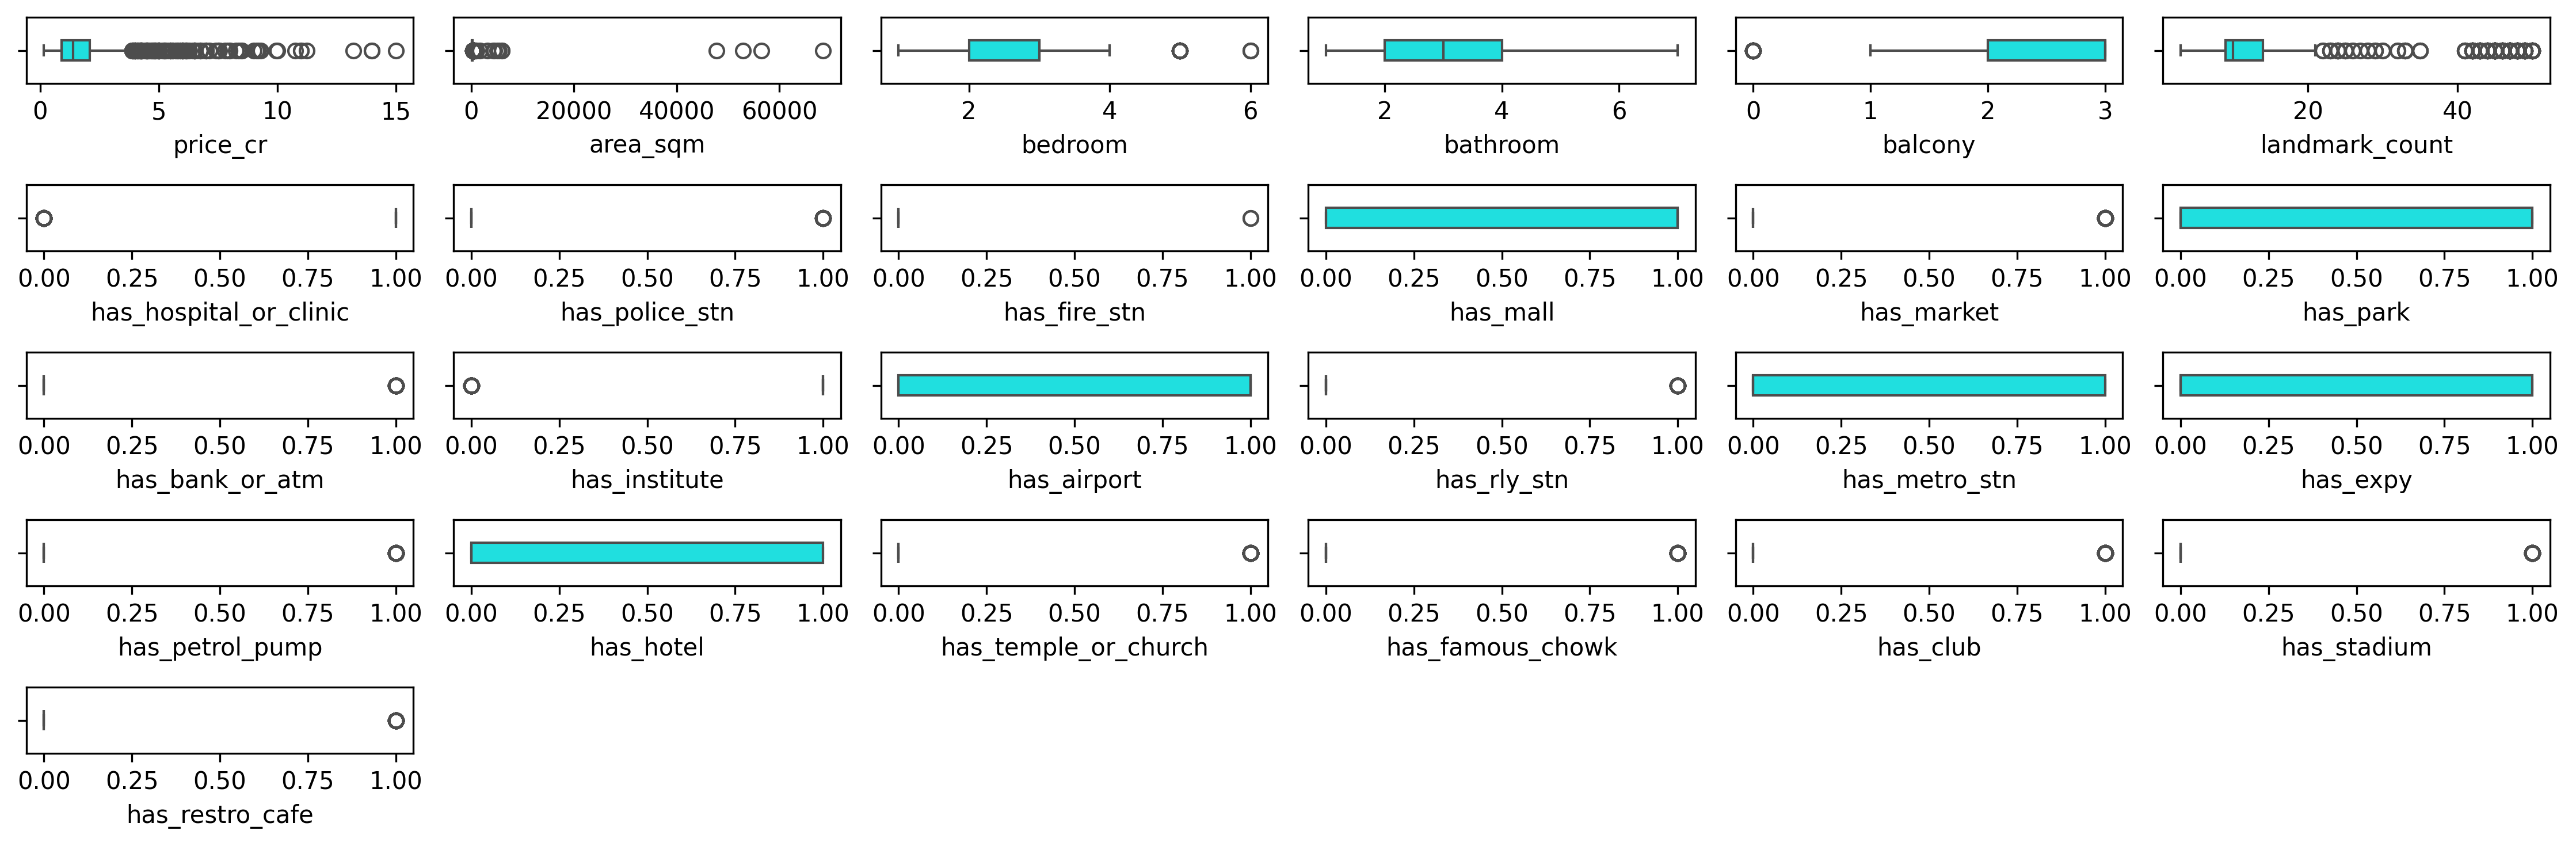

In [15]:
fig = plt.figure(figsize=(15,5),dpi=300)
i = 0
for col in ['price_cr', 'area_sqm', 'bedroom', 'bathroom', 'balcony',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe']:
    if df[col].dtype in ('int64', 'float64'):
        i += 1
        plt.subplot(df.shape[1]//6, 6, i)
        sns.boxplot(data=df, x=col, width=0.3, color='cyan')
plt.tight_layout()
plt.show()

In [16]:
np.percentile(df['area_sqm'], 99.6)

1278.654079999947

In [17]:
np.percentile(df['area_sqm'], 99.7)

4347.294210000045

In [18]:
#from 99.6 percentile to 99.7 percentile, there is a huge difference in the area,
#it seems to be outlier

In [19]:
df[df['area_sqm'] > np.percentile(df['area_sqm'], 99.6)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
76,5401.48,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,pyramid elite,gurgaon,0.46
107,52884.41,2.0,2.0,2.0,0.0,sector 95,12.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature the roselia,gurgaon,0.45
1281,4270.38,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.24
1283,56479.10,2.0,2.0,1.0,1.0,sector 95,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,ramsons kshitij,gurgaon,0.31
1284,5101.96,2.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.33
1285,5984.07,3.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38
1286,3195.96,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.21
1407,4534.69,1.0,1.0,2.0,1.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature the serenas,sohna,0.28
1941,47788.95,2.0,2.0,1.0,0.0,sector 107,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature global solera 2,gurgaon,0.51
2286,5994.94,2.0,2.0,2.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38


In [20]:
#there are 12 rows with exceptionally high area for a flat/apartment.
#even though the number of bhk is still 1,2 and 3.
#also, the price is below 1 crore INR which seems highly unlikely.
#there seem to be typos in the area.
#let's correct it.
df[df['area_sqm'] > np.percentile(df['area_sqm'], 99.6)].index

Index([76, 107, 1281, 1283, 1284, 1285, 1286, 1407, 1941, 2286, 2380, 2388], dtype='int64')

In [21]:
df.query("index in [77, 108, 1282, 1284, 1285, 1286, 1287, 1408, 1943, 2289, 2392]")
#all the rows with 1,2,3 bhk (removed 4bhk)

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
77,340.95,5.0,5.0,3.0,1.0,sector 66,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,emaar mgf palm terraces,gurgaon,4.50
108,69.68,2.0,2.0,1.0,0.0,sector 4,48.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,not applicable,gurgaon,0.42
1282,298.40,1.0,1.0,1.0,0.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.18
1284,5101.96,2.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.33
1285,5984.07,3.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38
1286,3195.96,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.21
1287,34.01,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.20
1408,117.43,2.0,2.0,3.0,1.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,mid,new,eldeco accolade,sohna,0.73
1943,187.66,4.0,4.0,3.0,0.0,sector 92,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,sare crescent parc royal greens phase 1,gurgaon,1.00
2289,146.04,2.0,2.0,3.0,1.0,sector 79,10.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,super built up,low,new,godrej 101,gurgaon,1.30


In [22]:
error_index = [77, 108, 1282, 1284, 1285, 1286, 1287, 1408, 1943, 2289, 2392]
for ix in error_index:
    print(df.loc[ix, 'area_sqm'])

340.95
69.68
298.4
5101.96
5984.07
3195.96
34.01
117.43
187.66
146.04
185.81


In [23]:
for ix in error_index:
    df.loc[ix, 'area_sqm'] /= 10

In [24]:
for ix in error_index:
    print(df.loc[ix, 'area_sqm'])

34.095
6.968000000000001
29.839999999999996
510.196
598.4069999999999
319.596
3.401
11.743
18.766
14.604
18.581


In [25]:
df[df['area_sqm'] > np.percentile(df['area_sqm'], 99.87)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
107,52884.41,2.0,2.0,2.0,0.0,sector 95,12.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature the roselia,gurgaon,0.45
1283,56479.10,2.0,2.0,1.0,1.0,sector 95,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,ramsons kshitij,gurgaon,0.31
1941,47788.95,2.0,2.0,1.0,0.0,sector 107,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature global solera 2,gurgaon,0.51
2388,68483.20,2.0,2.0,2.0,0.0,sector 33,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,built up,high,new,hcbs sports ville,sohna,0.35


In [26]:
#still there are rows, which are outliers due to typo
df[df['area_sqm'] > np.percentile(df['area_sqm'], 99.87)].index

Index([107, 1283, 1941, 2388], dtype='int64')

In [27]:
error_index = [108, 1284, 1943, 2392]
for ix in error_index:
    print(df.loc[ix, 'area_sqm'])

6.968000000000001
510.196
18.766
18.581


In [28]:
for ix in error_index:
    df.loc[ix, 'area_sqm'] /= 10

In [29]:
for ix in error_index:
    print(df.loc[ix, 'area_sqm'])

0.6968000000000001
51.019600000000004
1.8765999999999998
1.8580999999999999


In [30]:
df['price_cr'] = df['price_cr']*1.7    #inflation adjustment for 2021 to 2026

In [31]:
df.to_csv('data/07_flats_EDA.csv', index=False)